In [63]:
import json
import sqlite3

file_path = r"data\processed\processed_raw_videos_20260630T202419Z.json"

with open(file_path, "r", encoding="utf-8") as file:
    data = json.load(file)

In [5]:
type(data)
for key in data:
    print(key)

videos
comments


In [6]:
data.keys()

dict_keys(['videos', 'comments'])

In [64]:
db_path = r"data\youtube_pipeline.db"

conn = sqlite3.connect(db_path)
cursor = conn.cursor()

In [8]:
cursor.execute("SELECT * FROM sqlite_master WHERE type='table';")

tables = cursor.fetchall()
print(tables)

[('table', 'videos', 'videos', 2, 'CREATE TABLE videos (\n                video_id      TEXT PRIMARY KEY,\n                title         TEXT,\n                channel_name  TEXT,\n                channel_id    TEXT,\n                published_at  TEXT,\n                description   TEXT,\n                view_count    INTEGER DEFAULT 0,\n                like_count    INTEGER DEFAULT 0,\n                comment_count INTEGER DEFAULT 0\n            )'), ('table', 'comments', 'comments', 4, 'CREATE TABLE comments (\n                id            INTEGER PRIMARY KEY AUTOINCREMENT,\n                video_id      TEXT,\n                author        TEXT,\n                text          TEXT,\n                published_at  TEXT,\n                FOREIGN KEY (video_id) REFERENCES videos(video_id)\n            )'), ('table', 'sqlite_sequence', 'sqlite_sequence', 5, 'CREATE TABLE sqlite_sequence(name,seq)')]


In [9]:
import pandas as pd

df = pd.read_sql_query("SELECT * FROM videos;", conn)

df.head()

,video_id,title,channel_name,channel_id,published_at,description,view_count,like_count,comment_count
0,1XECx2DCW2A,كـــرداســـة | أحداث كرداسة.. ملحمة البطولة وا...,Podcast El Masyada,UCcjo-PzMKtCD0jX8d_7X7vQ,2026-06-30T20:00:06Z,كـــرداســـة | قصة حقيقية من ملفات ظابط مباحث ...,3557,387,94
1,DqxcsA3mDLw,"""إنت وظباطك... اخلوا القسم حالًا"" 😳 فصل من أصع...",Podcast El Masyada,UCcjo-PzMKtCD0jX8d_7X7vQ,2026-06-29T21:36:30Z,شاهد الحلقات الكاملة من بودكاست المصيدة من هنا...,8503,503,49
2,XXMqOnGIByo,مــــزاج دلـــيفري | كل حاجة كانت متوفرة.. وا...,Podcast El Masyada,UCcjo-PzMKtCD0jX8d_7X7vQ,2026-06-26T18:00:06Z,مــــزاج دلـــيفري | قصة حقيقية من ملفات ظابط...,162546,5727,1051
3,zzXaIn_h5D8,مزاج دليفري | كل طلب كان ليه سعر.. لكن اللي كا...,Podcast El Masyada,UCcjo-PzMKtCD0jX8d_7X7vQ,2026-06-25T10:31:54Z,شاهد الحلقات الكاملة من بودكاست المصيدة من هنا...,7295,303,24
4,ceU4H-0J_Io,الـبسـاتين | خمس أرواح راحت.. بس الجريمة دي بد...,Podcast El Masyada,UCcjo-PzMKtCD0jX8d_7X7vQ,2026-06-23T18:00:06Z,الـبسـاتين | قصة حقيقية من ملفات ظابط مباحث\n\...,122303,4715,544


In [15]:

conn = sqlite3.connect(r"C:\Users\ITHives\Desktop\youtube-pipeline\data\youtube_pipeline.db")

tables = pd.read_sql_query(
    "SELECT name FROM sqlite_master WHERE type='table';",
    conn
)

print(tables)

              name
0           videos
1         comments
2  sqlite_sequence


In [16]:
for table in tables["name"]:
    df = pd.read_sql_query(f"SELECT * FROM {table}", conn)
    df.to_csv(f"{table}.csv", index=False, encoding="utf-8-sig")

conn.close()

In [65]:
import os
import sqlite3
import pandas as pd

# الاتصال بقاعدة البيانات
db_path = r"C:\Users\ITHives\Desktop\youtube-pipeline\data\youtube_pipeline.db"
conn = sqlite3.connect(db_path)

# إنشاء مجلد csv إذا لم يكن موجودًا
output_folder = r"data\csv"
os.makedirs(output_folder, exist_ok=True)

# جلب أسماء الجداول
tables = pd.read_sql_query(
    "SELECT name FROM sqlite_master WHERE type='table';",
    conn
)

# تحويل كل جدول إلى CSV
for table in tables["name"]:
    df = pd.read_sql_query(f"SELECT * FROM {table}", conn)
    output_path = os.path.join(output_folder, f"{table}.csv")
    df.to_csv(output_path, index=False, encoding="utf-8-sig")
    print(f"Saved: {output_path}")

conn.close()

Saved: data\csv\videos.csv
Saved: data\csv\comments.csv
Saved: data\csv\sqlite_sequence.csv


In [24]:
comments = pd.read_csv("data/csv/comments.csv")
comments.head()


,id,video_id,author,text,published_at
0,1,1XECx2DCW2A,@ahmedramzy597,الواحد عمره ما كان يتخيل ان المصريين يقتلوا بع...,2026-06-30T20:59:07Z
1,2,1XECx2DCW2A,@amanybahgat7288,رجال مصر اللى حاميين شرفنا و ارواحنا.,2026-06-30T20:58:39Z
2,3,1XECx2DCW2A,@مهاابوغالى-ح2ل,الله يرحم شهداء وطننا مصر الحبيبه ياريت قر...,2026-06-30T20:57:54Z
3,4,1XECx2DCW2A,@GadEid-i1y,امجد بيه مافيش ولا عمليه فشلت معاكم والمجرم طل...,2026-06-30T20:57:40Z
4,5,1XECx2DCW2A,@jemmyadams5466,Great work 🎉🎉 New York,2026-06-30T20:57:06Z


In [25]:
comments.describe()

,id
count,6979.000000
mean,3490.000000
std,2014.808097
min,1.000000
25%,1745.500000
50%,3490.000000
75%,5234.500000
max,6979.000000


In [26]:
comments.info()

<class 'pandas.DataFrame'>
RangeIndex: 6979 entries, 0 to 6978
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   id            6979 non-null   int64
 1   video_id      6979 non-null   str  
 2   author        6979 non-null   str  
 3   text          6979 non-null   str  
 4   published_at  6979 non-null   str  
dtypes: int64(1), str(4)
memory usage: 272.7 KB


In [28]:
videos = pd.read_csv("data/csv/videos.csv")
videos.head()

,video_id,title,channel_name,channel_id,published_at,description,view_count,like_count,comment_count
0,1XECx2DCW2A,كـــرداســـة | أحداث كرداسة.. ملحمة البطولة وا...,Podcast El Masyada,UCcjo-PzMKtCD0jX8d_7X7vQ,2026-06-30T20:00:06Z,كـــرداســـة | قصة حقيقية من ملفات ظابط مباحث ...,3557,387,94
1,DqxcsA3mDLw,"""إنت وظباطك... اخلوا القسم حالًا"" 😳 فصل من أصع...",Podcast El Masyada,UCcjo-PzMKtCD0jX8d_7X7vQ,2026-06-29T21:36:30Z,شاهد الحلقات الكاملة من بودكاست المصيدة من هنا...,8503,503,49
2,XXMqOnGIByo,مــــزاج دلـــيفري | كل حاجة كانت متوفرة.. وا...,Podcast El Masyada,UCcjo-PzMKtCD0jX8d_7X7vQ,2026-06-26T18:00:06Z,مــــزاج دلـــيفري | قصة حقيقية من ملفات ظابط...,162546,5727,1051
3,zzXaIn_h5D8,مزاج دليفري | كل طلب كان ليه سعر.. لكن اللي كا...,Podcast El Masyada,UCcjo-PzMKtCD0jX8d_7X7vQ,2026-06-25T10:31:54Z,شاهد الحلقات الكاملة من بودكاست المصيدة من هنا...,7295,303,24
4,ceU4H-0J_Io,الـبسـاتين | خمس أرواح راحت.. بس الجريمة دي بد...,Podcast El Masyada,UCcjo-PzMKtCD0jX8d_7X7vQ,2026-06-23T18:00:06Z,الـبسـاتين | قصة حقيقية من ملفات ظابط مباحث\n\...,122303,4715,544


In [31]:
videos.describe()

,view_count,like_count,comment_count
count,6.000000e+01,60.000000,60.000000
mean,2.916039e+05,10631.566667,700.483333
std,3.535916e+05,11030.444849,684.774081
min,3.111000e+03,197.000000,8.000000
25%,2.694200e+04,1406.500000,65.000000
50%,2.023010e+05,8543.000000,641.500000
75%,3.456585e+05,13718.750000,945.250000
max,1.405427e+06,39048.000000,2987.000000


In [30]:
videos.info()

<class 'pandas.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   video_id       60 non-null     str  
 1   title          60 non-null     str  
 2   channel_name   60 non-null     str  
 3   channel_id     60 non-null     str  
 4   published_at   60 non-null     str  
 5   description    48 non-null     str  
 6   view_count     60 non-null     int64
 7   like_count     60 non-null     int64
 8   comment_count  60 non-null     int64
dtypes: int64(3), str(6)
memory usage: 4.3 KB


In [32]:
videos["published_at"] = pd.to_datetime(videos["published_at"])

In [33]:
videos["day_name"] = videos["published_at"].dt.day_name()

In [34]:
day_counts = (
    videos["day_name"]
    .value_counts()
    .reindex([
        "Monday",
        "Tuesday",
        "Wednesday",
        "Thursday",
        "Friday",
        "Saturday",
        "Sunday"
    ])
)

**Number of Videos Published by Day of Week**

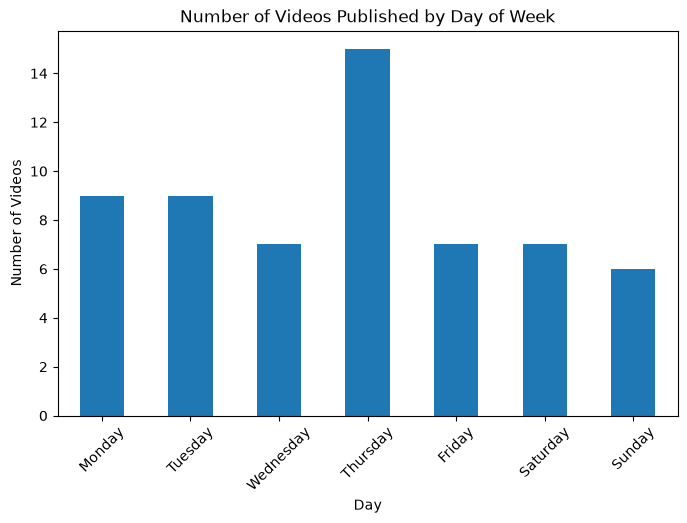

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

day_counts.plot(kind="bar")

plt.title("Number of Videos Published by Day of Week")
plt.xlabel("Day")
plt.ylabel("Number of Videos")

plt.xticks(rotation=45)

plt.show()

**Views vs Likes (Scatter Plot)**


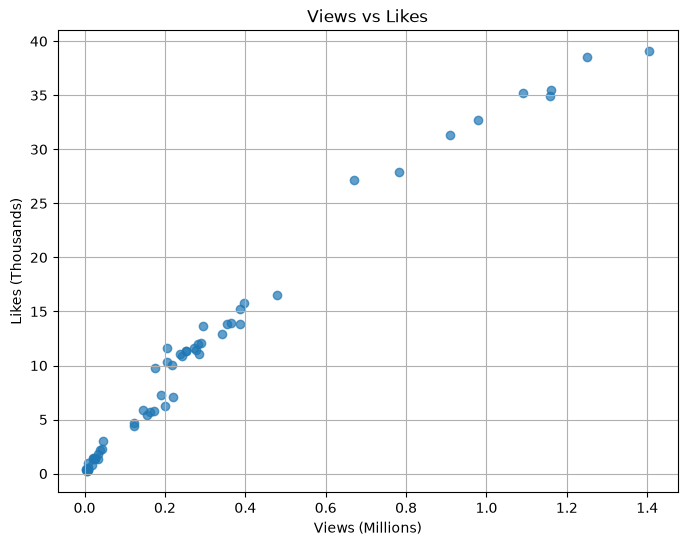

In [54]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    videos["view_count"] / 1_000_000,
    videos["like_count"] / 1_000,
    alpha=0.7
)

plt.title("Views vs Likes")
plt.xlabel("Views (Millions)")
plt.ylabel("Likes (Thousands)")

plt.grid(True)
plt.show()

**Average Views per Channel**

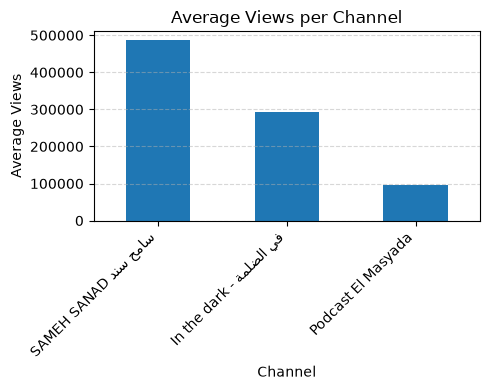

In [62]:
avg_views = (
    videos.groupby("channel_name")["view_count"]
    .mean()
    .sort_values(ascending=False)
)


plt.figure(figsize=(5, 4))

avg_views.plot(kind="bar")

plt.title("Average Views per Channel")
plt.xlabel("Channel")
plt.ylabel("Average Views")

plt.xticks(rotation=45, ha="right")

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()